# **Part 04:**
# **Verification of Exact Solutions and Convergence Analysis of the FEM Diffusion Solver**

## **Objective**

The main objective of this part is to verify the accuracy and convergence of the finite element diffusion solver developed in the previous parts.

The numerical FEM solution is compared with a known analytical solution. Two convergence studies are then performed:

1. Spatial convergence by decreasing the mesh width $h$.
2. Temporal convergence by decreasing the time-step size $\Delta t$.

The expected results are:

$$
\|e_h\|_{L^2}=O(h^2)
$$

for linear triangular finite elements, and

$$
\|e_{\Delta t}\|_{L^2}=O(\Delta t)
$$

for the implicit Euler method.

---

## **Governing Diffusion Equation**

The time-dependent diffusion equation is

$$
\frac{\partial c}{\partial t}
=
D\nabla^2c
\qquad \text{in } \Omega,
$$

where:

* $c(x,y,t)$ is the concentration;
* $D$ is the diffusion coefficient;
* $\nabla^2c$ is the Laplacian of concentration;
* $\Omega=[0,1]\times[0,1]$ is the computational domain.

The Laplacian in two dimensions is

$$
\nabla^2c
=
\frac{\partial^2c}{\partial x^2}
+
\frac{\partial^2c}{\partial y^2}.
$$

---

## **Boundary Condition**

Zero-flux boundary conditions are applied on the complete outer boundary:

$$
-D\nabla c\cdot\mathbf{n}=0
\qquad \text{on } \partial\Omega,
$$

where $\mathbf{n}$ is the outward unit normal vector.

This condition means that no concentration enters or leaves the domain.

---

## **Analytical Solution**

The analytical solution used to verify the numerical solver is

$$
c_{\mathrm{exact}}(x,y,t)
=
1+
0.25e^{-2\pi^2Dt}
\cos(\pi x)\cos(\pi y).
$$

This function satisfies the diffusion equation and the zero-flux boundary conditions.

At $t=0$, the initial condition is

$$
c(x,y,0)
=
1+
0.25\cos(\pi x)\cos(\pi y).
$$

The same initial condition is used for the FEM solution.

---

## **Finite Element Formulation**

The finite element approximation is written as

$$
c_h(x,y,t)
=
\sum_{j=1}^{N_{\mathrm{nodes}}}
c_j(t)\phi_j(x,y),
$$

where $\phi_j$ are the linear finite element basis functions.

The semi-discrete FEM system is

$$
M\frac{d\mathbf{c}}{dt}
+
K\mathbf{c}
=
\mathbf{0},
$$

where:

* $M$ is the global mass matrix;
* $K$ is the global stiffness matrix;
* $\mathbf{c}$ is the vector of nodal concentration values.

---

## **Local Mass Matrix**

For a triangular element with area $A_e$, the local mass matrix is

$$
M^{(e)}
=
\frac{A_e}{12}
\begin{bmatrix}
2 & 1 & 1\\
1 & 2 & 1\\
1 & 1 & 2
\end{bmatrix}.
$$

---

## **Basis-Function Gradients**

For a triangle with vertices

$$
(x_1,y_1),\qquad
(x_2,y_2),\qquad
(x_3,y_3),
$$

its signed area is

$$
A_e
=
\frac{1}{2}
\left[
(x_2-x_1)(y_3-y_1)
-
(x_3-x_1)(y_2-y_1)
\right].
$$

The coefficients used to calculate the basis-function gradients are

$$
b_1=y_2-y_3,
\qquad
b_2=y_3-y_1,
\qquad
b_3=y_1-y_2,
$$

and

$$
d_1=x_3-x_2,
\qquad
d_2=x_1-x_3,
\qquad
d_3=x_2-x_1.
$$

The code names the second set `c_coefficients`, but $d_i$ is used here to avoid confusion with concentration $c$.

The gradient of each basis function is

$$
\nabla\phi_i
=
\frac{1}{2A_e}
\begin{bmatrix}
b_i\\
d_i
\end{bmatrix}.
$$

---

## **Local Stiffness Matrix**

The local stiffness-matrix entries are

$$
K_{ij}^{(e)}
=
D
\int_{\Omega_e}
\nabla\phi_i\cdot\nabla\phi_j\,d\Omega.
$$

Because the basis-function gradients are constant inside a linear triangular element,

$$
K_{ij}^{(e)}
=
DA_e
\left(
\nabla\phi_i\cdot\nabla\phi_j
\right).
$$

In matrix form,

$$
K^{(e)}
=
DA_eGG^T,
$$

where $G$ contains the basis-function gradients.

---

## **Implicit Euler Time Discretization**

The time derivative is approximated by

$$
\frac{d\mathbf{c}}{dt}
\approx
\frac{\mathbf{c}^{n+1}-\mathbf{c}^{n}}
{\Delta t}.
$$

Substituting this approximation into the FEM system gives

$$
M
\frac{\mathbf{c}^{n+1}-\mathbf{c}^{n}}
{\Delta t}
+
K\mathbf{c}^{n+1}
=
\mathbf{0}.
$$

After rearrangement,

$$
\left(M+\Delta tK\right)\mathbf{c}^{n+1}
=
M\mathbf{c}^{n}.
$$

Therefore, the system matrix is

$$
A=M+\Delta tK.
$$

The matrix is factorized once using LU factorization:

$$
PA=LU.
$$

The factors are reused at every time step to calculate the new concentration vector efficiently.

---

## **Algorithm**
## Step 1: Define the Exact Solution

Define

$$
c_{\mathrm{exact}}(x,y,t)
=
1+
0.25e^{-2\pi^2Dt}
\cos(\pi x)\cos(\pi y).
$$

Use its value at $t=0$ as the initial condition:

$$
\mathbf{c}^{0}
=
c_{\mathrm{exact}}(x_i,y_i,0).
$$

---

## Step 2: Generate the Triangular Mesh

For $N_x=N_y=N$, calculate the mesh width:

$$
h=\frac{1}{N}.
$$

Generate the nodal coordinates and divide every rectangular cell into two triangular elements.

The total number of nodes is

$$
N_{\mathrm{nodes}}=(N+1)^2,
$$

and the total number of triangular elements is

$$
N_{\mathrm{elements}}=2N^2.
$$

---

## Step 3: Assemble the FEM Matrices

For every triangular element:

1. Calculate its signed area $A_e$.
2. Calculate the basis-function gradients.
3. Construct the local mass matrix $M^{(e)}$.
4. Construct the local stiffness matrix $K^{(e)}$.
5. Add the local entries to the corresponding global matrices.

This produces the global matrices

$$
M=\sum_e M^{(e)}
$$

and

$$
K=\sum_e K^{(e)}.
$$

---

## Step 4: Determine the Time-Step Size

Calculate the number of time steps:

$$
N_t
=
\operatorname{round}
\left(
\frac{T}{\Delta t}
\right).
$$

To ensure that the simulation ends exactly at $T$, use

$$
\Delta t_{\mathrm{actual}}
=
\frac{T}{N_t}.
$$

---

## Step 5: Construct the Implicit Euler Matrix

Construct

$$
A
=
M+\Delta t_{\mathrm{actual}}K.
$$

Perform LU factorization of $A$ once before starting the time loop.

---

## Step 6: Perform Time Integration

At every time level, calculate the right-hand side:

$$
\mathbf{b}^{n}
=
M\mathbf{c}^{n}.
$$

Then solve

$$
A\mathbf{c}^{n+1}
=
\mathbf{b}^{n}.
$$

Repeat this process until the final time $T$ is reached.

---

## Step 7: Calculate the Error Vector

At the final time, calculate the exact nodal solution:

$$
\mathbf{c}_{\mathrm{exact}}
=
c_{\mathrm{exact}}(x_i,y_i,T).
$$

The nodal error vector is

$$
\mathbf{e}
=
\mathbf{c}_{\mathrm{FEM}}
-
\mathbf{c}_{\mathrm{exact}}.
$$

---

## Step 8: Calculate the Discrete $L^2$ Error

The discrete $L^2$ error is calculated using the global mass matrix:

$$
E_{L^2}
=
\sqrt{\mathbf{e}^TM\mathbf{e}}.
$$

A smaller value of $E_{L^2}$ indicates better agreement between the numerical and analytical solutions.

---

## Step 9: Calculate the Maximum Nodal Error

The maximum nodal error is

$$
E_{\max}
=
\max_i|e_i|.
$$

This measures the largest absolute difference at any mesh node.

---

## Step 10: Perform the Spatial Convergence Study

Use the mesh divisions

$$
N=4,\;8,\;12,\;16
$$

with mesh widths

$$
h=\frac{1}{N}.
$$

Use a small time step,

$$
\Delta t=10^{-4},
$$

to reduce the effect of temporal error.

For two successive meshes, calculate the spatial convergence rate:

$$
p_i
=
\frac{
\log\left(E_{i-1}/E_i\right)
}{
\log\left(h_{i-1}/h_i\right)
}.
$$

For linear triangular finite elements, the expected discrete $L^2$ convergence rate is

$$
p\approx2.
$$

---

## Step 11: Perform the Temporal Convergence Study

Use a relatively fine fixed mesh:

$$
N=24.
$$

Use the time-step sizes

$$
\Delta t
=
0.02,\;0.01,\;0.005,\;0.0025.
$$

For two successive time steps, calculate the temporal convergence rate:

$$
q_i
=
\frac{
\log\left(E_{i-1}/E_i\right)
}{
\log\left(\Delta t_{i-1}/\Delta t_i\right)
}.
$$

For the implicit Euler method, the expected temporal convergence rate is

$$
q\approx1.
$$

---

## Step 12: Verify the Convergence Results

The spatial convergence study is successful when

$$
p\approx2,
$$

and the temporal convergence study is successful when

$$
q\approx1.
$$

These results confirm that the numerical solver has the expected spatial and temporal accuracy.

---

## Step 13: Visualize the Results

Generate the following figures:

1. FEM concentration solution at the final time.
2. Exact concentration solution at the final time.
3. Absolute-error distribution.
4. Spatial $L^2$ error against mesh width on a log-log scale.
5. Temporal $L^2$ error against time-step size on a log-log scale.

The numerical convergence curves are compared with the reference relationships

$$
E_h\propto h^2
$$

and

$$
E_{\Delta t}\propto\Delta t.
$$


Number of nodes: 169
Number of elements: 288
Actual time-step size: 0.001
Discrete L2 error: 0.0005615377641450068
Maximum nodal error: 0.0015298342173067914


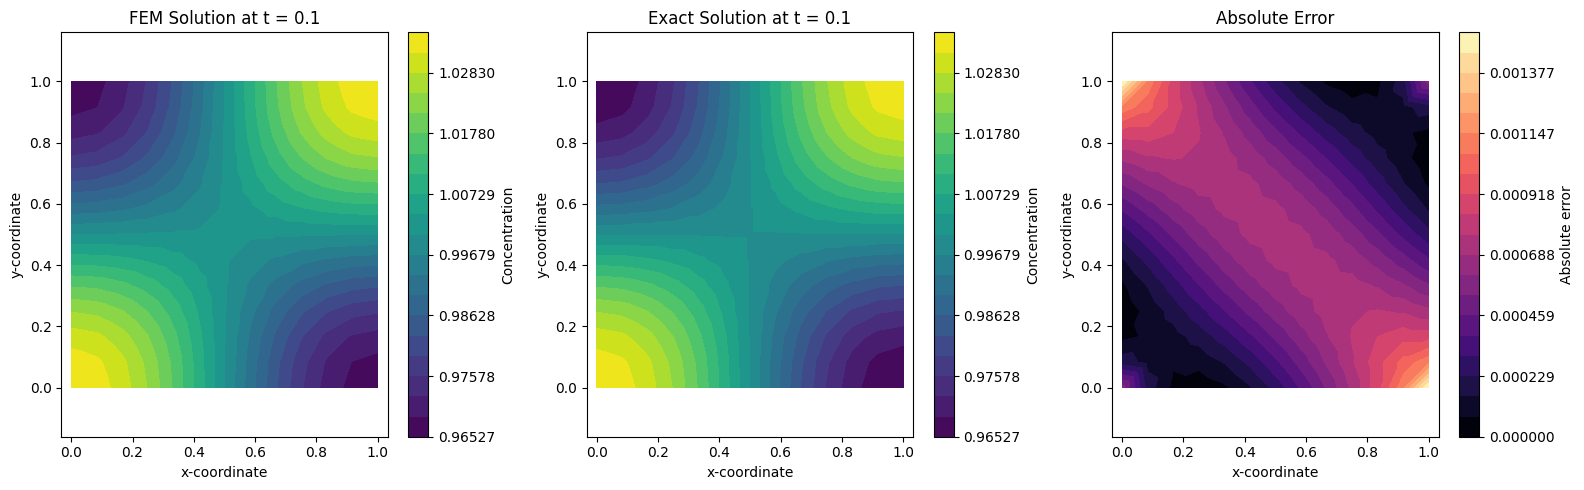

Mesh divisions: 4 | h: 0.25 | L2 error: 0.006014865137393611
Mesh divisions: 8 | h: 0.125 | L2 error: 0.0016500751015438666
Mesh divisions: 12 | h: 0.08333333333333333 | L2 error: 0.0007379419920814534
Mesh divisions: 16 | h: 0.0625 | L2 error: 0.00040836749639273044

Spatial Convergence Results
 N        h          L2 error        Rate
 4    0.250000    6.014865e-03    -
 8    0.125000    1.650075e-03    1.8660
12    0.083333    7.379420e-04    1.9847
16    0.062500    4.083675e-04    2.0568
Time step: 0.02 | L2 error: 0.006156872672550003
Time step: 0.01 | L2 error: 0.0031173744843965706
Time step: 0.005 | L2 error: 0.0015182997277459786
Time step: 0.0025 | L2 error: 0.0007026619501637

Temporal Convergence Results
 Time step       L2 error          Rate
0.020000        6.156873e-03        -
0.010000        3.117374e-03        0.9819
0.005000        1.518300e-03        1.0379
0.002500        7.026620e-04        1.1116
Spatial convergence is approximately second order.
Temporal conver

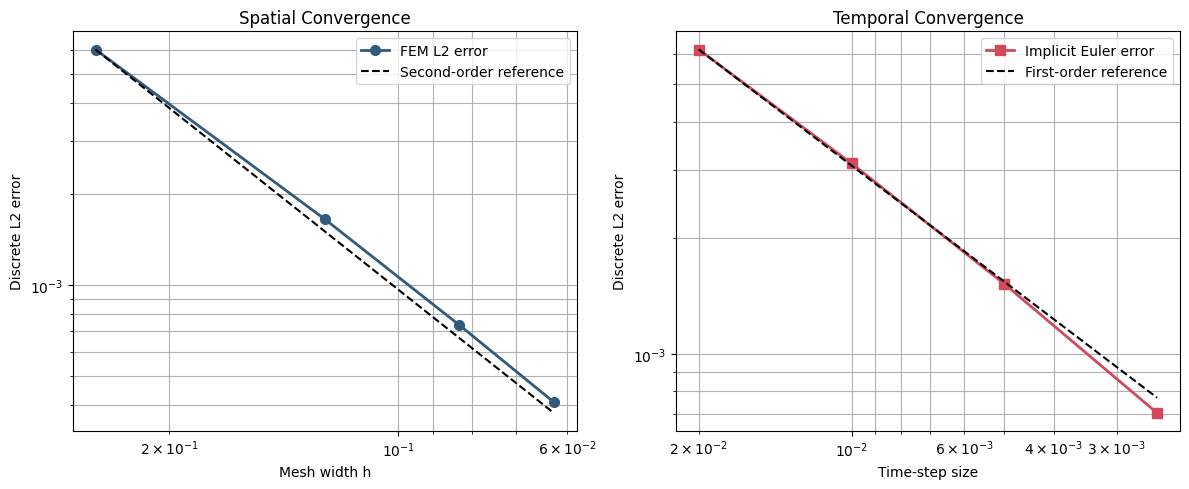

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import lu_factor, lu_solve
np.set_printoptions(precision=8,suppress=True)
def exact_solution(nodes, time,diffusion_coefficient=1.0):
    x_coordinates = nodes[:, 0]
    y_coordinates = nodes[:, 1]
    exact_values = (1.0 + 0.25* np.exp(-2.0 * np.pi ** 2 * diffusion_coefficient * time) * np.cos(np.pi * x_coordinates) * np.cos(np.pi * y_coordinates))
    return exact_values
def solve_diffusion_problem(number_of_divisions,time_step,final_time=0.1,diffusion_coefficient=1.0):
    Lx = 1.0
    Ly = 1.0
    Nx = number_of_divisions
    Ny = number_of_divisions
    x = np.linspace( 0.0, Lx, Nx + 1)
    y = np.linspace( 0.0, Ly, Ny + 1)
    X, Y = np.meshgrid(x,y,indexing="xy")
    nodes = np.column_stack((X.ravel(),Y.ravel()))
    elements = []
    for j in range(Ny):
        for i in range(Nx):
            n1 = j * (Nx + 1) + i
            n2 = n1 + 1
            n3 = n1 + (Nx + 1)
            n4 = n3 + 1
            elements.append([n1, n2, n4])
            elements.append([n1, n4, n3])
    elements = np.asarray(elements,dtype=int)
    number_of_nodes = len(nodes)
    number_of_elements = len(elements)
    # Initialize the FEM matrices
    global_mass = np.zeros((number_of_nodes,number_of_nodes ))
    global_stiffness = np.zeros(( number_of_nodes, number_of_nodes))
    for element_index in range(number_of_elements):
        element = elements[element_index]
        coordinates = nodes[element]
        x1, y1 = coordinates[0]
        x2, y2 = coordinates[1]
        x3, y3 = coordinates[2]
        area = 0.5 * ((x2 - x1) * (y3 - y1) -(x3 - x1) * (y2 - y1))
        if area <= 0.0:
            raise ValueError("A reversed or degenerate element was found.")
        b_coefficients = np.array([y2 - y3,y3 - y1,y1 - y2])
        c_coefficients = np.array([x3 - x2,x1 - x3,x2 - x1])
        basis_gradients = np.column_stack((b_coefficients,c_coefficients)) / (2.0 * area)
        local_mass = (area / 12.0) * np.array([[2.0, 1.0, 1.0],
            [1.0, 2.0, 1.0],
            [1.0, 1.0, 2.0]])
        local_stiffness = ( diffusion_coefficient * area * (basis_gradients @ basis_gradients.T))
        for local_i in range(3):
            global_i = element[local_i]
            for local_j in range(3):
                global_j = element[local_j]
                global_mass[global_i, global_j] += local_mass[local_i,local_j]
                global_stiffness[ global_i, global_j] += local_stiffness[local_i,local_j]
    # Apply implicit Euler time integration
    number_of_time_steps = int(round(final_time / time_step))
    actual_time_step = (final_time / number_of_time_steps)
    system_matrix = (global_mass + actual_time_step * global_stiffness)
    lu_matrix, pivot_indices = lu_factor( system_matrix )
    # Initial condition taken from the exact solution
    numerical_solution = exact_solution(nodes,time=0.0,diffusion_coefficient=diffusion_coefficient)
    for time_step_index in range(number_of_time_steps):
        right_hand_side = (global_mass @ numerical_solution)
        numerical_solution = lu_solve((lu_matrix, pivot_indices),right_hand_side)
    exact_final_solution = exact_solution(nodes, time=final_time, diffusion_coefficient=diffusion_coefficient)
    error_vector = (numerical_solution - exact_final_solution )
    discrete_L2_error = np.sqrt(error_vector @ global_mass @ error_vector)
    maximum_error = np.max(np.abs(error_vector))
    return ( nodes, elements, global_mass, global_stiffness, numerical_solution, exact_final_solution, error_vector, discrete_L2_error, maximum_error, actual_time_step)
reference_divisions = 12
reference_time_step = 0.001
final_time = 0.1
D = 1.0

( reference_nodes,
    reference_elements,
    reference_mass,
    reference_stiffness,
    numerical_solution,
    exact_final_solution,
    error_vector,
    reference_L2_error,
    reference_maximum_error,
    actual_time_step) = solve_diffusion_problem(number_of_divisions=reference_divisions,
    time_step=reference_time_step,
    final_time=final_time,
    diffusion_coefficient=D)
print("Number of nodes:",len(reference_nodes))
print("Number of elements:",len(reference_elements))
print("Actual time-step size:", actual_time_step)
print("Discrete L2 error:",reference_L2_error)
print("Maximum nodal error:",reference_maximum_error)
# Plot the exact and numerical solution
minimum_value = min(np.min(numerical_solution),np.min(exact_final_solution))
maximum_value = max(np.max(numerical_solution),np.max(exact_final_solution))
solution_levels = np.linspace(minimum_value,maximum_value,21)
absolute_error = np.abs(error_vector)
error_levels = np.linspace( 0.0, np.max(absolute_error), 21)
plt.figure(figsize=(16, 5))
# Numerical solution
plt.subplot(1, 3, 1)
numerical_plot = plt.tricontourf(
    reference_nodes[:, 0],
    reference_nodes[:, 1],
    reference_elements,
    numerical_solution,
    levels=solution_levels,
    cmap="viridis")
plt.colorbar(numerical_plot,label="Concentration")
plt.title(f"FEM Solution at t = {final_time}")
plt.xlabel("x-coordinate")
plt.ylabel("y-coordinate")
plt.axis("equal")
# Exact solution
plt.subplot(1, 3, 2)
exact_plot = plt.tricontourf(
    reference_nodes[:, 0],
    reference_nodes[:, 1],
    reference_elements,
    exact_final_solution,
    levels=solution_levels,
    cmap="viridis")
plt.colorbar( exact_plot, label="Concentration")
plt.title( f"Exact Solution at t = {final_time}")
plt.xlabel("x-coordinate")
plt.ylabel("y-coordinate")
plt.axis("equal")
# Absolute error
plt.subplot(1, 3, 3)
error_plot = plt.tricontourf(
    reference_nodes[:, 0],
    reference_nodes[:, 1],
    reference_elements,
    absolute_error,
    levels=error_levels,
    cmap="magma")
plt.colorbar(error_plot,label="Absolute error")
plt.title("Absolute Error")
plt.xlabel("x-coordinate")
plt.ylabel("y-coordinate")
plt.axis("equal")
plt.tight_layout()
plt.savefig("exact_numerical_error_comparison.png", dpi=300, bbox_inches="tight")
plt.show()
# Perform the spatial convergence study
mesh_divisions = np.array([4,8,12,16])
mesh_widths = 1.0 / mesh_divisions
# A small time step reduces the temporal error
spatial_study_time_step = 0.0001
spatial_L2_errors = np.zeros(len(mesh_divisions))
spatial_maximum_errors = np.zeros(len(mesh_divisions))
for study_index in range( len(mesh_divisions)):
    current_divisions = int(mesh_divisions[study_index])
    (current_nodes,
        current_elements,
        current_mass,
        current_stiffness,
        current_numerical_solution,
        current_exact_solution,
        current_error_vector,
        current_L2_error,
        current_maximum_error,
        current_time_step) = solve_diffusion_problem(number_of_divisions=current_divisions,
        time_step=spatial_study_time_step,
        final_time=final_time,
        diffusion_coefficient=D)
    spatial_L2_errors[study_index] = (current_L2_error)
    spatial_maximum_errors[study_index] = (current_maximum_error)
    print("Mesh divisions:",current_divisions,"| h:", mesh_widths[study_index], "| L2 error:", current_L2_error)
# Calculate the spatial convergence rates
spatial_convergence_rates = np.full(len(mesh_divisions),np.nan)
for study_index in range(1,len(mesh_divisions)):
    spatial_convergence_rates[study_index] = (np.log(spatial_L2_errors[study_index - 1]/spatial_L2_errors[study_index])/np.log(mesh_widths[study_index - 1]/mesh_widths[study_index]))
print("\nSpatial Convergence Results")
print(" N        h          L2 error        Rate")

for study_index in range(len(mesh_divisions)):
    if study_index == 0:
        rate_text = "-"
    else:
        rate_text = (f"{spatial_convergence_rates[study_index]:.4f}")

    print(f"{mesh_divisions[study_index]:2d}"f"    {mesh_widths[study_index]:.6f}"f"    {spatial_L2_errors[study_index]:.6e}"f"    {rate_text}")
# Perform the temporal convergence study
temporal_mesh_divisions = 24
time_step_sizes = np.array([0.0200,0.0100,0.0050,0.0025])
temporal_L2_errors = np.zeros(len(time_step_sizes))
temporal_maximum_errors = np.zeros(len(time_step_sizes))
for study_index in range(len(time_step_sizes)):
    current_time_step = (time_step_sizes[study_index])
    (current_nodes,
        current_elements,
        current_mass,
        current_stiffness,
        current_numerical_solution,
        current_exact_solution,
        current_error_vector,
        current_L2_error,
        current_maximum_error,
        actual_time_step) = solve_diffusion_problem(
        number_of_divisions=temporal_mesh_divisions,
        time_step=current_time_step,
        final_time=final_time,
        diffusion_coefficient=D)
    temporal_L2_errors[study_index] = (current_L2_error)
    temporal_maximum_errors[study_index] = (current_maximum_error)
    print("Time step:",current_time_step,"| L2 error:",current_L2_error)
  # Calculate temporal convergence rate
temporal_convergence_rates = np.full(len(time_step_sizes),np.nan)
for study_index in range(1,len(time_step_sizes)):
    temporal_convergence_rates[study_index] = ( np.log(temporal_L2_errors[study_index - 1]/temporal_L2_errors[study_index])
        /np.log(time_step_sizes[study_index - 1]/time_step_sizes[study_index]))
print("\nTemporal Convergence Results")
print(" Time step       L2 error          Rate")
for study_index in range(len(time_step_sizes)):
    if study_index == 0:
        rate_text = "-"
    else:
        rate_text = (f"{temporal_convergence_rates[study_index]:.4f}")
    print( f"{time_step_sizes[study_index]:.6f}" f"        {temporal_L2_errors[study_index]:.6e}" f"        {rate_text}")
# Verify the convergence rate
valid_spatial_rates = (spatial_convergence_rates[1:])
valid_temporal_rates = (temporal_convergence_rates[1:])
assert np.all(valid_spatial_rates > 1.7), "The expected spatial convergence was not observed."
assert np.all(valid_temporal_rates > 0.8), "The expected temporal convergence was not observed."
assert np.all(valid_temporal_rates < 1.3), "The temporal convergence rates are unexpected."
print("Spatial convergence is approximately second order.")
print( "Temporal convergence is approximately first order.")
print("All convergence checks passed successfully.")
# Reference second-order spatial line
spatial_reference_line = (spatial_L2_errors[0]* (mesh_widths/mesh_widths[0]) ** 2)
# Reference first-order temporal line
temporal_reference_line = ( temporal_L2_errors[0] * ( time_step_sizes/time_step_sizes[0]))
plt.figure(figsize=(12, 5))
# Spatial convergence
plt.subplot(1, 2, 1)
plt.loglog(mesh_widths,spatial_L2_errors,"o-",color="#315A7D",linewidth=2,markersize=7,label="FEM L2 error")
plt.loglog(mesh_widths,spatial_reference_line,"--",color="black",linewidth=1.5,label="Second-order reference")
plt.title("Spatial Convergence")
plt.xlabel("Mesh width h")
plt.ylabel("Discrete L2 error")
plt.grid(True, which="both")
plt.legend()
# Display refinement from left to right
plt.gca().invert_xaxis()
# Temporal convergence
plt.subplot(1, 2, 2)
plt.loglog(time_step_sizes,temporal_L2_errors,"s-",color="#D1495B",linewidth=2,markersize=7,label="Implicit Euler error")
plt.loglog(time_step_sizes,temporal_reference_line,"--",color="black",linewidth=1.5,label="First-order reference")
plt.title("Temporal Convergence")
plt.xlabel("Time-step size")
plt.ylabel("Discrete L2 error")
plt.grid(True, which="both")
plt.legend()
# Display refinement from left to right
plt.gca().invert_xaxis()
plt.tight_layout()
plt.savefig("spatial_temporal_convergence.png",dpi=300,bbox_inches="tight")
plt.show()


## **Conclusion**

In Part 4, the finite element diffusion solver was verified using a known analytical solution. For a mesh containing 169 nodes and 288 triangular elements, the discrete $L^2$ error was approximately $5.62\times10^{-4}$, while the maximum nodal error was approximately $1.53\times10^{-3}$. The numerical and exact concentration distributions showed very close agreement.

During the spatial convergence study, the $L^2$ error decreased from $6.01\times10^{-3}$ to $4.08\times10^{-4}$ as the mesh was refined. The calculated convergence rates approached 2, confirming the expected second-order spatial accuracy of the linear triangular finite element method.

During the temporal convergence study, the error decreased from $6.16\times10^{-3}$ to $7.03\times10^{-4}$ as the time-step size was reduced. The convergence rates remained close to 1, confirming the expected first-order accuracy of the implicit Euler method.

Therefore, the spatial discretization, time-integration method, and FEM implementation are working correctly. The verified solver provides a reliable numerical foundation for introducing coupled ion transport and pH evolution.
